In [1]:
# Importer les bibliothèques nécessaires
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import morphology, measure
from scipy import ndimage

In [2]:
# Charger l'image BLOOD1.TIF en niveaux de gris
image = cv2.imread('BLOOD1.TIF', cv2.IMREAD_GRAYSCALE)
if image is None:
    print("Erreur : l'image 'BLOOD1.TIF' n'a pas pu être chargée.")
else:
    print("Image 'BLOOD1.TIF' chargée avec succès.")

Image 'BLOOD1.TIF' chargée avec succès.


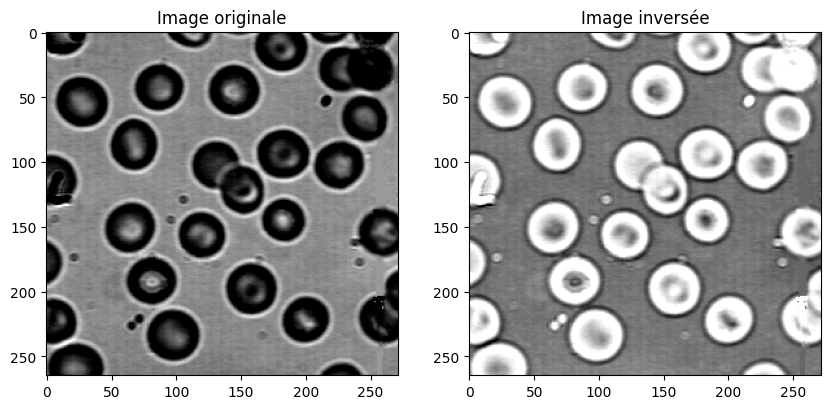

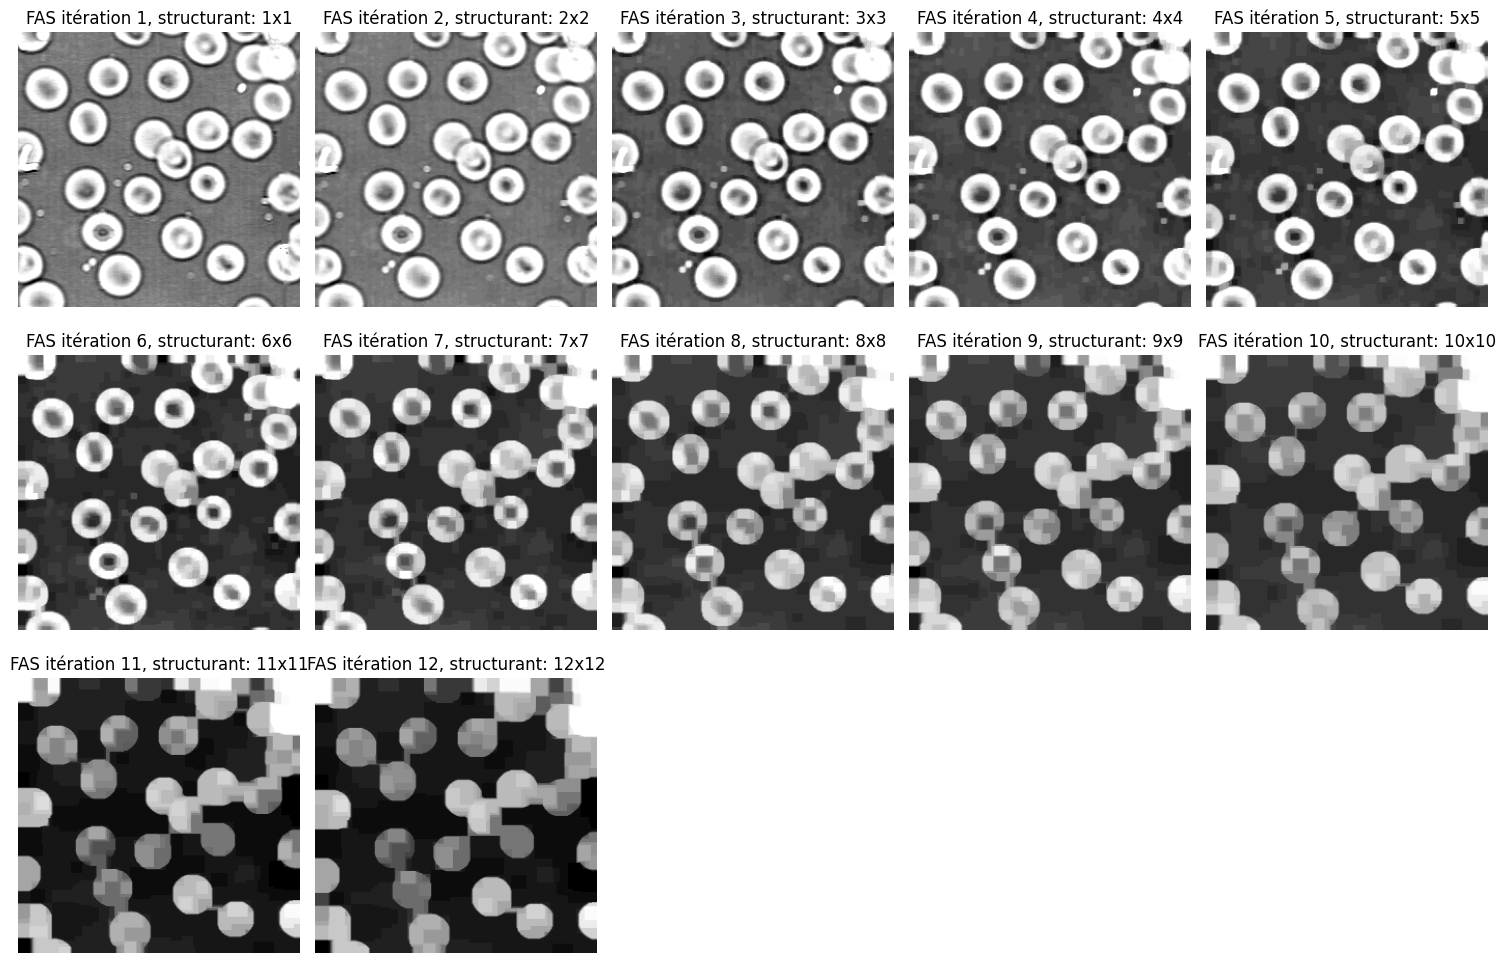

In [4]:
# Étape 1 : Inverser l'image pour que les cellules de sang soient en blanc
# et l'arrière-plan en noir
image_inv = cv2.bitwise_not(image)

# Afficher l'image originale et l'image inversée
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Image originale")
plt.subplot(1, 2, 2)
plt.imshow(image_inv, cmap='gray')
plt.title("Image inversée")
plt.show()

# Fonction pour appliquer le filtre alterné séquentiel (FAS)
def filtre_alterne_sequentiel(image, initial_size=1, iterations=12):
    # Copie de l'image pour éviter de la modifier directement
    img_fas = image.copy()

    # Préparation de la figure pour les subplots
    plt.figure(figsize=(15, 10))
    rows = 3  # 3 lignes de subplots pour mieux visualiser
    cols = (iterations // rows) + 1

    for i in range(iterations):
        # Créer un élément structurant de taille croissante
        size = initial_size + i  # Incrémentation progressive de la taille
        structuring_element = cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))

        # Appliquer une ouverture puis une fermeture (FAS blanc)
        opened = cv2.morphologyEx(img_fas, cv2.MORPH_OPEN, structuring_element)
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, structuring_element)

        # Mettre à jour img_fas
        img_fas = closed

        # Afficher chaque itération dans un subplot
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_fas, cmap='gray')
        plt.title(f"FAS itération {i+1}, structurant: {size}x{size}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    return img_fas

# Appliquer FAS sur l'image inversée
result_fas = filtre_alterne_sequentiel(image_inv)

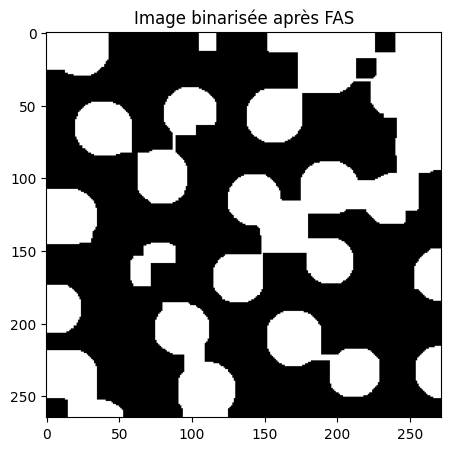

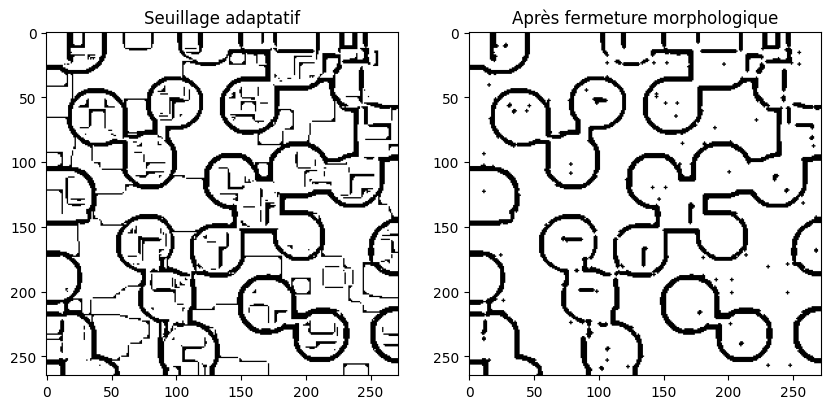

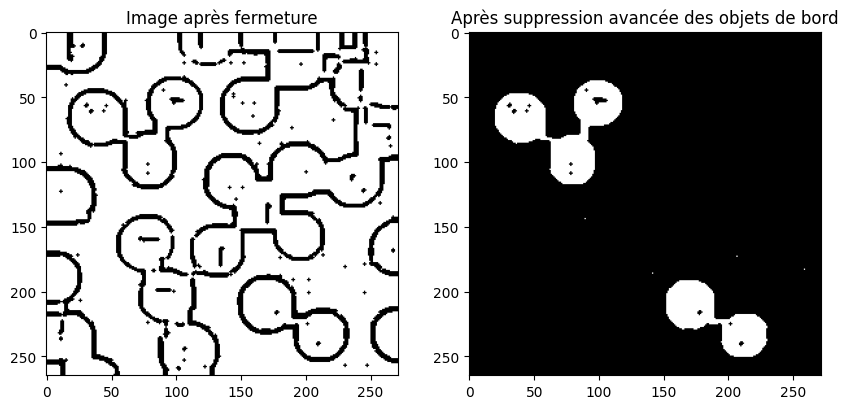

In [ ]:
# Étape 2 : Suppression des objets touchant le bord

# Binariser l'image pour éviter les problèmes d'interférence de pixels
# Nous utilisons le seuillage d'Otsu pour créer une image binaire
_, image_binary = cv2.threshold(result_fas, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


# Nous utilisons le seuillage d'Otsu pour créer une image binaire
# + Utiliser un seuillage adaptatif pour garder les bords faibles
image_adaptive_thresh = cv2.adaptiveThreshold(
    result_fas, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2
)


# Afficher l'image binarisée
plt.figure(figsize=(10, 5))
plt.imshow(image_binary, cmap='gray')
plt.title("Image binarisée après FAS")
plt.show()


# Appliquer une fermeture morphologique pour lisser les formes des cellules
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
image_closed = cv2.morphologyEx(image_adaptive_thresh, cv2.MORPH_CLOSE, kernel)

# Afficher l'image après seuillage adaptatif et fermeture
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_adaptive_thresh, cmap='gray')
plt.title("Seuillage adaptatif")
plt.subplot(1, 2, 2)
plt.imshow(image_closed, cmap='gray')
plt.title("Après fermeture morphologique")
plt.show()



# Labeliser les objets connectés dans l'image après fermeture
labeled, num_labels = ndimage.label(image_closed)

# Créer un masque pour garder les objets sans connexion excessive aux bords
mask_border_objects = np.zeros_like(labeled)

# Définir la marge de bord pour vérifier les objets partiellement visibles aux bords
border_margin = 5

# Créer un masque représentant la zone de bord de 2 pixels de large
border_mask = np.zeros_like(labeled)
border_mask[:border_margin, :] = 1         # bord supérieur
border_mask[-border_margin:, :] = 1        # bord inférieur
border_mask[:, :border_margin] = 1         # bord gauche
border_mask[:, -border_margin:] = 1        # bord droit

# Parcourir chaque objet identifié dans l'image
for i in range(1, num_labels + 1):
    # Créer un masque temporaire pour chaque objet
    obj = (labeled == i)

    # Vérifier si l'objet touche le bord en utilisant le masque de bord
    if np.any(border_mask & obj):
        # Pour les objets qui touchent le bord mais sont très larges, on garde leur partie interne
        # Identifier les régions centrales pour les objets connectés aux bords
        distance_from_edge = ndimage.distance_transform_edt(~obj)

        # Seuil de distance pour définir la zone centrale (ajustable selon besoin)
        inner_mask = distance_from_edge > 10  # Garder seulement la partie interne

        # Ajouter la partie centrale au masque final
        mask_border_objects += obj & inner_mask
    else:
        # Si l'objet est complètement à l'intérieur, on l'ajoute au masque final
        mask_border_objects += obj

# Afficher l'image après suppression et traitement des objets de bord
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_closed, cmap='gray')
plt.title("Image après fermeture")
plt.subplot(1, 2, 2)
plt.imshow(mask_border_objects, cmap='gray')
plt.title("Après suppression avancée des objets de bord")
plt.show()

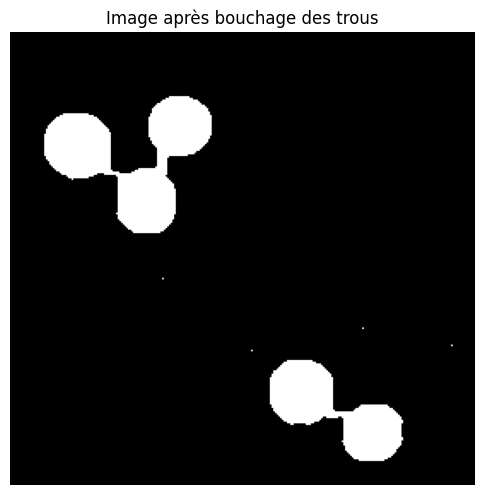

In [ ]:
# Étape 3 : Bouchage des trous pour remplir les régions intérieures des cellules
# On utilise binary_fill_holes pour combler les trous à l'intérieur des cellules

# Appliquer le remplissage de trous pour conserver les cellules pleines
filled_image = ndimage.binary_fill_holes(mask_border_objects).astype(np.uint8) * 255

# Afficher l'image après l'opération de bouchage des trous
plt.figure(figsize=(6, 6))
plt.imshow(filled_image, cmap='gray')
plt.title("Image après bouchage des trous")
plt.axis("off")
plt.show()

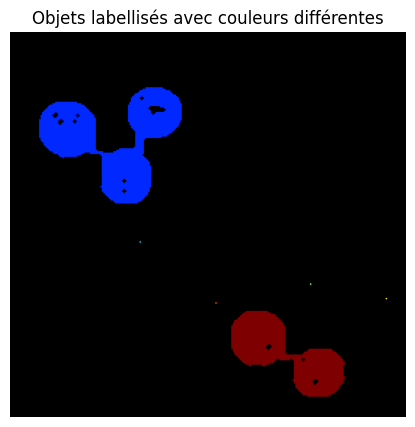

Nombre de cellules identifiées : 5


In [ ]:
# Étape 4 : Labellisation des objets restants

# Labellisation pour donner un identifiant unique à chaque cellule de sang
labeled_image, num_features = ndimage.label(mask_border_objects)

# Créer une image colorée pour afficher les objets labellisés
# Utiliser un colormap pour colorer les labels de manière distincte
colored_labels = np.zeros((*labeled_image.shape, 3), dtype=np.uint8)  # Image vide en couleur (RGB)

# Générer des couleurs distinctes pour chaque label
num_colors = num_features + 1  # +1 pour le fond
colors = plt.cm.jet(np.linspace(0, 1, num_colors))[:, :3] * 255  # Couleurs en RGB (0-255)

# Parcourir chaque label et assigner une couleur
for i in range(1, num_features + 1):
    colored_labels[labeled_image == i] = colors[i]

# Afficher l'image avec les objets labellisés colorés
plt.figure(figsize=(10, 5))
plt.imshow(colored_labels)
plt.title("Objets labellisés avec couleurs différentes")
plt.axis("off")
plt.show()

print(f"Nombre de cellules identifiées : {num_features - 1}")


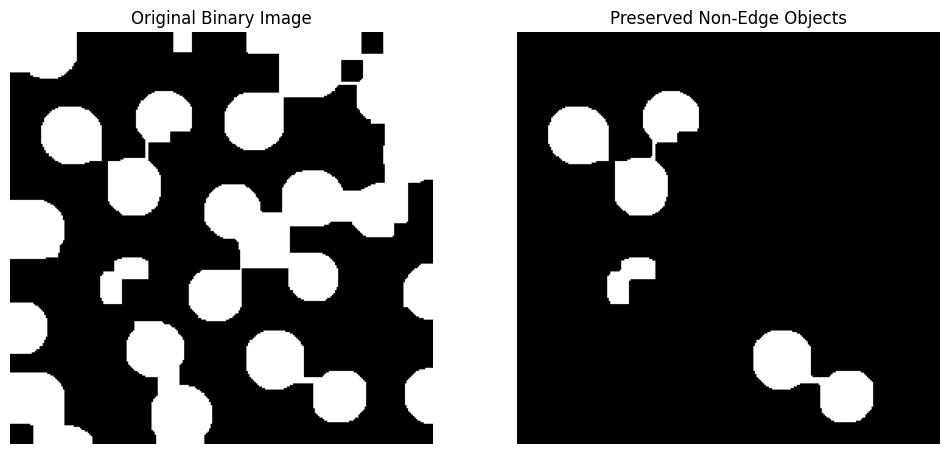

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

# Step 1: Binary Thresholding
_, binary_image = cv2.threshold(result_fas, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Step 2: Label the objects
labeled_image, num_labels = ndimage.label(binary_image)

# Step 3: Create an edge mask (1-pixel margin mask around the image edges)
edge_mask = np.zeros_like(labeled_image)
edge_mask[0, :] = 1          # Top row
edge_mask[-1, :] = 1         # Bottom row
edge_mask[:, 0] = 1          # Left column
edge_mask[:, -1] = 1         # Right column

# Step 4: Label edge-touching regions by applying the mask to labeled image
# This will mark objects that intersect the edge
edge_touching_labels = np.unique(labeled_image * edge_mask)

# Step 5: Create a new mask that excludes edge-touching labels
# Initialize a mask to keep non-edge objects
preserved_mask = np.zeros_like(labeled_image)

# Iterate over all labels to keep only non-edge touching parts
for label in range(1, num_labels + 1):
    if label not in edge_touching_labels:
        preserved_mask[labeled_image == label] = 1  # Keep non-edge touching objects

# Optional Step: Apply a morphological closing to smooth shapes and enhance separation
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
preserved_mask = cv2.morphologyEx(preserved_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)

# Display Results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(binary_image, cmap='gray')
plt.title("Original Binary Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(preserved_mask, cmap='gray')
plt.title("Preserved Non-Edge Objects")
plt.axis("off")
plt.show()


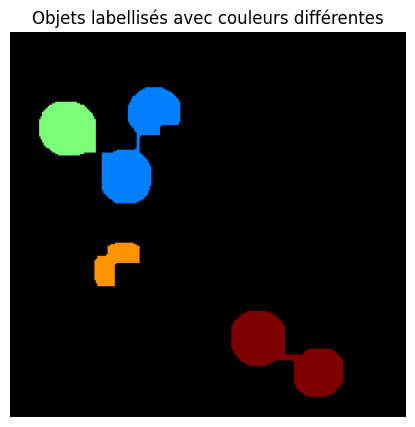

Nombre de cellules identifiées : 4


In [6]:
# Étape 4 : Labellisation des objets restants

# Labellisation pour donner un identifiant unique à chaque cellule de sang
labeled_image, num_features = ndimage.label(preserved_mask)  # Assumes `preserved_mask` from edge segmentation is used here

# Créer une image colorée pour afficher les objets labellisés
# Utiliser un colormap pour colorer les labels de manière distincte
colored_labels = np.zeros((*labeled_image.shape, 3), dtype=np.uint8)  # Image vide en couleur (RGB)

# Générer des couleurs distinctes pour chaque label
num_colors = num_features + 1  # +1 pour le fond
colors = plt.cm.jet(np.linspace(0, 1, num_colors))[:, :3] * 255  # Couleurs en RGB (0-255)

# Corriger les valeurs de couleurs pour être dans le bon format entier (0-255)
colors = colors.astype(np.uint8)

# Parcourir chaque label et assigner une couleur
for i in range(1, num_features + 1):
    colored_labels[labeled_image == i] = colors[i]

# Afficher l'image avec les objets labellisés colorés
plt.figure(figsize=(10, 5))
plt.imshow(colored_labels)
plt.title("Objets labellisés avec couleurs différentes")
plt.axis("off")
plt.show()

print(f"Nombre de cellules identifiées : {num_features}")

In [ ]:
image = cv2.imread('BLOOD1.TIF', cv2.IMREAD_GRAYSCALE)
if image is None:
    print("Erreur : l'image 'BLOOD1.TIF' n'a pas pu être chargée.")
else:
    print("Image 'BLOOD1.TIF' chargée avec succès.")






---
## Partie 2 : Squelettisation et Transformation de Ligne de Partage des Eaux (Watershed)


---



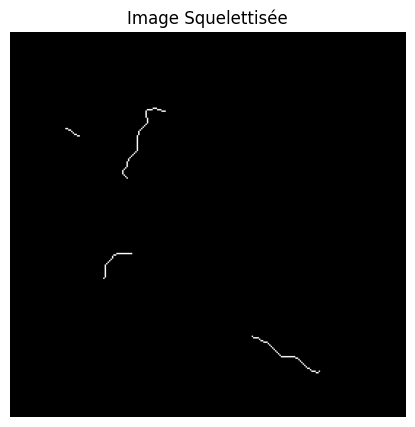

In [11]:
from skimage.morphology import skeletonize

# Appliquer la squelettisation sur l'image binaire
squelette = skeletonize(preserved_mask > 0.48)

# Afficher le squelette
plt.figure(figsize=(10, 5))
plt.imshow(squelette, cmap='gray')
plt.title("Image Squelettisée")
plt.axis("off")
plt.show()

In [ ]:
image = cv2.imread('', cv2.IMREAD_GRAYSCALE)
if image is None:
    print("Erreur : l'image 'BLOOD1.TIF' n'a pas pu être chargée.")
else:
    print("Image 'BLOOD1.TIF' chargée avec succès.")

In [27]:
!pip install watershed

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 84.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for watershed: filename=Watershed-2.2.2-py3-none-any.whl size=57023 sha256=967e674106ea9eb1fb2a551245511f1fb82344ec35dfd810536dd5b0b336e612
  Stored in directory: /root/.cache/pip/wheels/bf/d7/90/bcdf36d49e7ac0e09e61c1875578a7954d45819b9a134f2010
Successfully built watershed


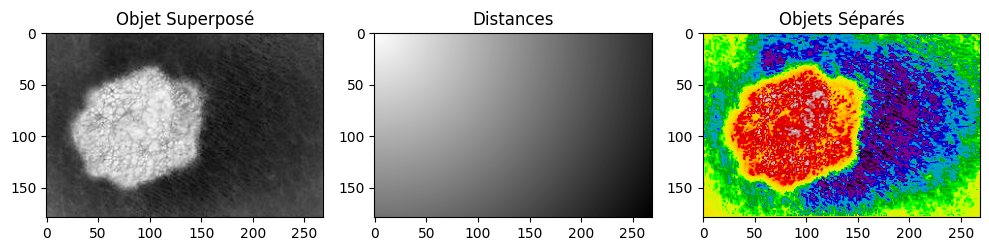

In [40]:
from skimage import morphology, feature, segmentation
from scipy import ndimage
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Charger l'image en RGB
image_rgb = cv2.imread("melanome.jpg")

# Convertir l'image en niveaux de gris
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2GRAY)

# Inverser l'image en niveaux de gris pour préparer la transformation de distance
image_inv = cv2.bitwise_not(image_gray)

# Créer un noyau pour le calcul du gradient
kernel = np.ones((3, 3), np.uint8)

# Calculer le gradient de l'image (en niveaux de gris) pour la transformation Watershed
gradient = cv2.morphologyEx(image_inv, cv2.MORPH_GRADIENT, kernel)

# Appliquer la transformation de distance
distance = ndimage.distance_transform_edt(image_inv)

# Trouver les minima locaux pour marquer les régions
local_minima = feature.peak_local_max(distance, footprint=np.ones((3, 3)), labels=image_inv)

# Créer une image de marqueurs vide (de la même taille que l'image inversée)
markers = np.zeros_like(image_inv, dtype=int)

# Placer les marqueurs dans les positions des minima locaux
markers[tuple(local_minima.T)] = np.arange(1, len(local_minima) + 1)

# Appliquer la transformation Watershed
labels = segmentation.watershed(-distance, markers, mask=image_inv)

# Afficher les résultats de la transformation de Watershed
plt.figure(figsize=(10, 5))

# Affichage de l'image avec les objets superposés
plt.subplot(1, 3, 1)
plt.imshow(image_inv, cmap=plt.cm.gray)
plt.title('Objet Superposé')

# Affichage des distances
plt.subplot(1, 3, 2)
plt.imshow(-distance, cmap=plt.cm.gray)
plt.title('Distances')

# Affichage de l'image après segmentation Watershed
plt.subplot(1, 3, 3)
plt.imshow(labels, cmap=plt.cm.nipy_spectral)
plt.title('Objets Séparés')

plt.tight_layout()
plt.show()


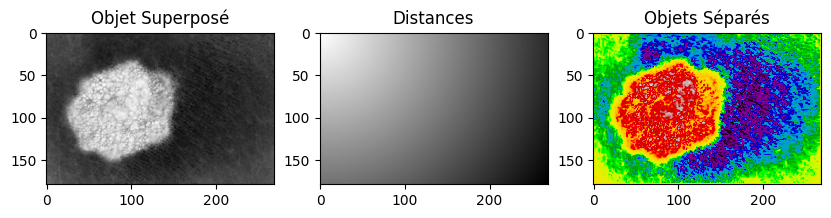

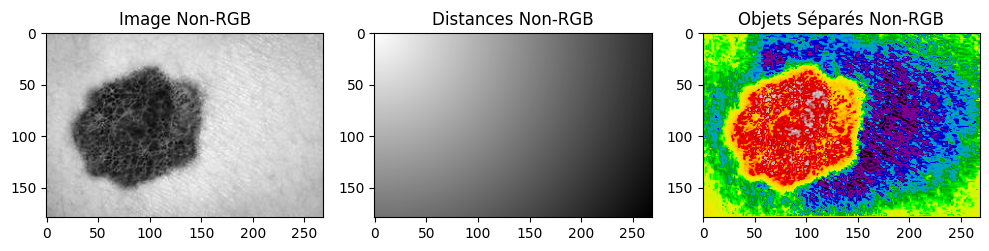

In [43]:
from skimage import morphology, feature, segmentation
from scipy import ndimage
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Charger l'image en RGB
image_rgb = cv2.imread("melanome.jpg")

# Convertir l'image en niveaux de gris
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2GRAY)

# Inverser l'image en niveaux de gris pour préparer la transformation de distance
image_inv = cv2.bitwise_not(image_gray)

# Créer un noyau pour le calcul du gradient
kernel = np.ones((3, 3), np.uint8)

# Calculer le gradient de l'image (en niveaux de gris) pour la transformation Watershed
gradient = cv2.morphologyEx(image_inv, cv2.MORPH_GRADIENT, kernel)

# Appliquer la transformation de distance
distance = ndimage.distance_transform_edt(image_inv)

# Trouver les minima locaux pour marquer les régions
local_minima = feature.peak_local_max(distance, footprint=np.ones((3, 3)), labels=image_inv)

# Créer une image de marqueurs vide (de la même taille que l'image inversée)
markers = np.zeros_like(image_inv, dtype=int)

# Placer les marqueurs dans les positions des minima locaux
markers[tuple(local_minima.T)] = np.arange(1, len(local_minima) + 1)

# Appliquer la transformation Watershed
labels = segmentation.watershed(-distance, markers, mask=image_inv)

# Afficher les résultats de la transformation de Watershed sur l'image inversée
plt.figure(figsize=(10, 5))

# Affichage de l'image avec les objets superposés
plt.subplot(1, 3, 1)
plt.imshow(image_inv, cmap=plt.cm.gray)
plt.title('Objet Superposé')

# Affichage des distances
plt.subplot(1, 3, 2)
plt.imshow(-distance, cmap=plt.cm.gray)
plt.title('Distances')

# Affichage de l'image après segmentation Watershed
plt.subplot(1, 3, 3)
plt.imshow(labels, cmap=plt.cm.nipy_spectral)
plt.title('Objets Séparés')

# Charger une autre image non-RGB pour la deuxième segmentation Watershed
image_non_rgb = cv2.imread("melanome.jpg", cv2.IMREAD_GRAYSCALE)

# Inverser cette image pour la transformation de distance
image_non_rgb_inv = cv2.bitwise_not(image_non_rgb)

# Appliquer la transformation de distance sur l'image non-RGB
distance_non_rgb = ndimage.distance_transform_edt(image_non_rgb_inv)

# Trouver les minima locaux pour marquer les régions
local_minima_non_rgb = feature.peak_local_max(distance_non_rgb, footprint=np.ones((3, 3)), labels=image_non_rgb_inv)

# Vérifier si des minima locaux ont été trouvés
if local_minima_non_rgb.size == 0:
    print("Aucun minima local trouvé dans l'image non-RGB")
else:
    # Créer une image de marqueurs vide pour l'image non-RGB
    markers_non_rgb = np.zeros_like(image_non_rgb_inv, dtype=int)

    # Placer les marqueurs dans les positions des minima locaux pour l'image non-RGB
    markers_non_rgb[tuple(local_minima_non_rgb.T)] = np.arange(1, len(local_minima_non_rgb) + 1)

    # Appliquer la transformation Watershed sur l'image non-RGB
    labels_non_rgb = segmentation.watershed(-distance_non_rgb, markers_non_rgb, mask=image_non_rgb_inv)

    # Afficher les résultats de Watershed pour l'image non-RGB
    plt.figure(figsize=(10, 5))

    # Affichage de l'image non-RGB
    plt.subplot(1, 3, 1)
    plt.imshow(image_non_rgb, cmap=plt.cm.gray)
    plt.title('Image Non-RGB')

    # Affichage des distances pour l'image non-RGB
    plt.subplot(1, 3, 2)
    plt.imshow(-distance_non_rgb, cmap=plt.cm.gray)
    plt.title('Distances Non-RGB')

    # Affichage de l'image après segmentation Watershed pour l'image non-RGB
    plt.subplot(1, 3, 3)
    plt.imshow(labels_non_rgb, cmap=plt.cm.nipy_spectral)
    plt.title('Objets Séparés Non-RGB')

plt.tight_layout()
plt.show()


L'image n'est pas binaire.


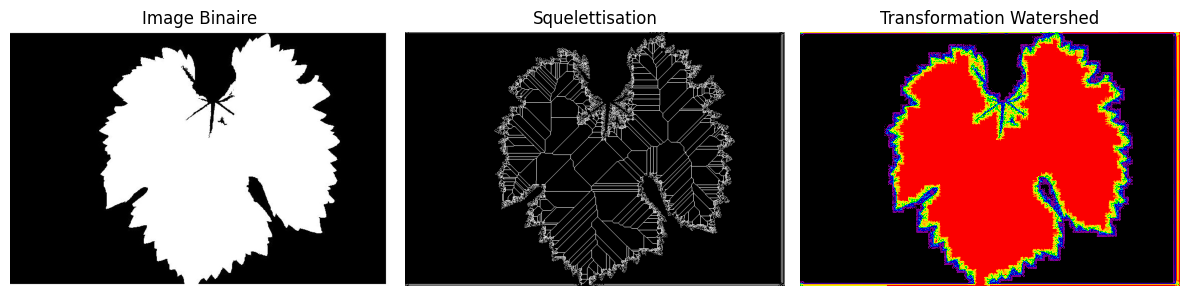

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import morphology, feature, segmentation
from scipy import ndimage

# Charger l'image binaire
image = cv2.imread('leaf1.jpg', cv2.IMREAD_GRAYSCALE)

# Vérifier que l'image est bien binaire (0 ou 255)
if np.unique(image).size > 2:
    print("L'image n'est pas binaire.")
else:
    print("L'image est binaire.")

# 1. Squelletisation (Skeletonization)
skeleton = morphology.skeletonize(image // 255)  # division par 255 pour transformer en 0 et 1

# 2. Transformation Watershed
# Appliquer la transformation de distance
distance = ndimage.distance_transform_edt(image)

# Trouver les minima locaux pour marquer les régions
local_minima = feature.peak_local_max(distance, footprint=np.ones((3, 3)), labels=image)

# Créer une image de marqueurs vide
markers = np.zeros_like(image, dtype=int)

# Placer les marqueurs dans les positions des minima locaux
markers[tuple(local_minima.T)] = np.arange(1, len(local_minima) + 1)

# Appliquer la transformation Watershed
labels = segmentation.watershed(-distance, markers, mask=image)

# Affichage des résultats
plt.figure(figsize=(12, 6))

# Affichage de l'image d'origine
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Image Binaire')
plt.axis('off')

# Affichage du résultat de la squeletteisation
plt.subplot(1, 3, 2)
plt.imshow(skeleton, cmap='gray')
plt.title('Squelettisation')
plt.axis('off')

# Affichage du résultat de la transformation Watershed
plt.subplot(1, 3, 3)
plt.imshow(labels, cmap='nipy_spectral')
plt.title('Transformation Watershed')
plt.axis('off')

# Afficher les résultats
plt.tight_layout()
plt.show()


L'image est déjà binaire.


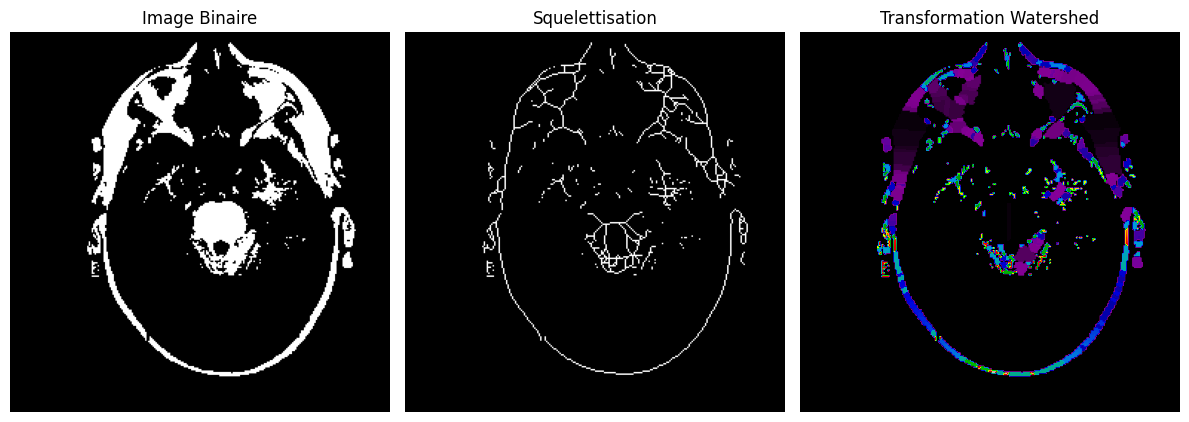

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import morphology, feature, segmentation
from scipy import ndimage

# Charger l'image binaire (image en niveaux de gris)
image = cv2.imread('brain.png', cv2.IMREAD_GRAYSCALE)

# Vérifier que l'image est bien binaire (0 ou 255)
# Si l'image n'est pas binaire, on peut la binariser
ret, image_bin = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Vérifier l'état de la binarisation
if np.unique(image_bin).size > 2:
    print("L'image a été binarisée.")
else:
    print("L'image est déjà binaire.")

# 1. Squelletisation (Skeletonization)
# Appliquer la squeletteisation sur l'image binaire
skeleton = morphology.skeletonize(image_bin // 255)  # division par 255 pour convertir en 0 et 1

# 2. Transformation Watershed
# Appliquer la transformation de distance
distance = ndimage.distance_transform_edt(image_bin)

# Trouver les minima locaux pour marquer les régions
local_minima = feature.peak_local_max(distance, footprint=np.ones((3, 3)), labels=image_bin)

# Créer une image de marqueurs vide
markers = np.zeros_like(image_bin, dtype=int)

# Placer les marqueurs dans les positions des minima locaux
markers[tuple(local_minima.T)] = np.arange(1, len(local_minima) + 1)

# Appliquer la transformation Watershed
labels = segmentation.watershed(-distance, markers, mask=image_bin)

# Affichage des résultats
plt.figure(figsize=(12, 6))

# Affichage de l'image d'origine binaire
plt.subplot(1, 3, 1)
plt.imshow(image_bin, cmap='gray')
plt.title('Image Binaire')
plt.axis('off')

# Affichage du résultat de la squeletteisation
plt.subplot(1, 3, 2)
plt.imshow(skeleton, cmap='gray')
plt.title('Squelettisation')
plt.axis('off')

# Affichage du résultat de la transformation Watershed
plt.subplot(1, 3, 3)
plt.imshow(labels, cmap='nipy_spectral')
plt.title('Transformation Watershed')
plt.axis('off')

# Afficher les résultats
plt.tight_layout()
plt.show()